In [1]:
!pip install pandas matplotlib seaborn plotly

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [7]:
matches = pd.read_csv('C:/Users/DELL/Desktop/ipl-analysis/data/matches.csv')
deliveries = pd.read_csv('C:/Users/DELL/Desktop/ipl-analysis/data/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print("\n--- Matches Columns ---")
print(matches.columns.tolist())

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)

--- Matches Columns ---
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [8]:
matches.head(3)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [9]:
# Standardize team names (they changed over seasons)
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Kings XI Punjab': 'Punjab Kings'
}

matches['team1'] = matches['team1'].replace(team_name_map)
matches['team2'] = matches['team2'].replace(team_name_map)
matches['winner'] = matches['winner'].replace(team_name_map)

# Drop ties and no-result matches
matches_clean = matches.dropna(subset=['winner'])
matches_clean = matches_clean[matches_clean['winner'] != 'Tie']

print(f"✅ Clean matches: {len(matches_clean)} out of {len(matches)}")
print(f"Seasons available: {sorted(matches_clean['season'].unique())}")

✅ Clean matches: 1090 out of 1095
Seasons available: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']


In [10]:
# Total matches played per team per season
team1 = matches_clean[['season', 'team1']].rename(columns={'team1': 'team'})
team2 = matches_clean[['season', 'team2']].rename(columns={'team2': 'team'})
matches_played = pd.concat([team1, team2])
matches_played = matches_played.groupby(['season', 'team']).size().reset_index(name='matches_played')

# Total wins per team per season
wins = matches_clean.groupby(['season', 'winner']).size().reset_index(name='wins')
wins.rename(columns={'winner': 'team'}, inplace=True)

# Merge both
performance = pd.merge(matches_played, wins, on=['season', 'team'], how='left')
performance['wins'] = performance['wins'].fillna(0)
performance['win_pct'] = (performance['wins'] / performance['matches_played'] * 100).round(1)

print("✅ Performance table created!")
print(performance.head(10))

✅ Performance table created!
    season                         team  matches_played  wins  win_pct
0  2007/08          Chennai Super Kings              16     9     56.2
1  2007/08               Delhi Capitals              14     7     50.0
2  2007/08        Kolkata Knight Riders              13     6     46.2
3  2007/08               Mumbai Indians              14     7     50.0
4  2007/08                 Punjab Kings              15    10     66.7
5  2007/08             Rajasthan Royals              16    13     81.2
6  2007/08  Royal Challengers Bangalore              14     4     28.6
7  2007/08          Sunrisers Hyderabad              14     2     14.3
8     2009          Chennai Super Kings              14     8     57.1
9     2009               Delhi Capitals              15    10     66.7


In [11]:
top_teams = [
    'Mumbai Indians',
    'Chennai Super Kings',
    'Kolkata Knight Riders',
    'Royal Challengers Bangalore',
    'Sunrisers Hyderabad',
    'Delhi Capitals'
]

perf_top = performance[performance['team'].isin(top_teams)]

print(f"✅ Filtered! Rows: {len(perf_top)}")
print(perf_top['team'].unique())

✅ Filtered! Rows: 99
['Chennai Super Kings' 'Delhi Capitals' 'Kolkata Knight Riders'
 'Mumbai Indians' 'Royal Challengers Bangalore' 'Sunrisers Hyderabad']


In [12]:
# Convert all seasons to single year format
def fix_season(s):
    s = str(s)
    if '/' in s:
        return int(s.split('/')[0])
    return int(s)

performance['season'] = performance['season'].apply(fix_season)
perf_top = performance[performance['team'].isin(top_teams)]

print("✅ Seasons fixed!")
print(sorted(perf_top['season'].unique()))

✅ Seasons fixed!
[np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [14]:
import os

# Create images folder if it doesn't exist
os.makedirs('C:/Users/DELL/Desktop/ipl-analysis/images', exist_ok=True)
print("✅ Images folder created!")

✅ Images folder created!


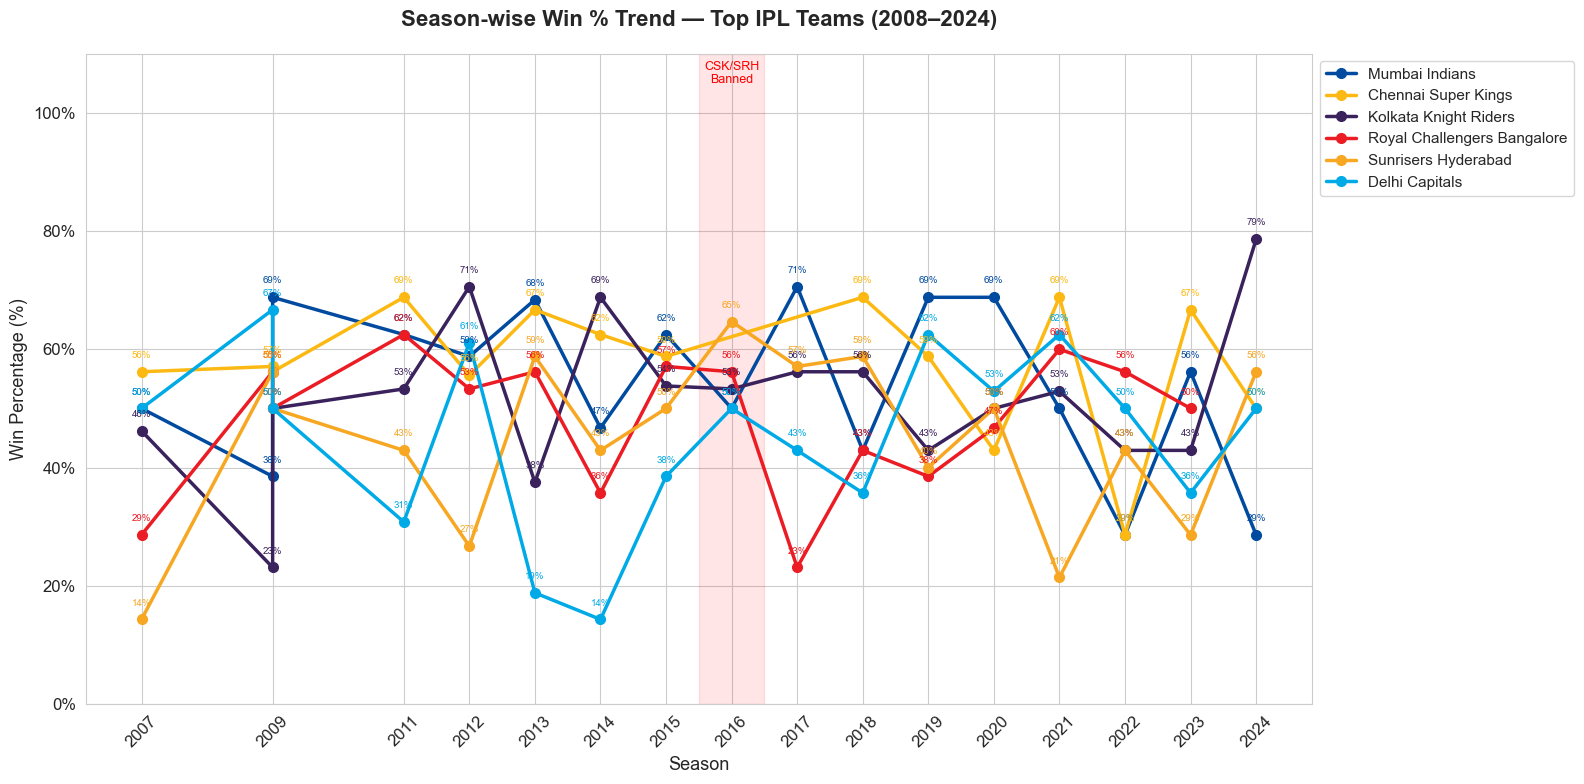

✅ Improved chart saved!


In [16]:
fig, ax = plt.subplots(figsize=(16, 8))

colors = {
    'Mumbai Indians': '#004BA0',
    'Chennai Super Kings': '#FDB913',
    'Kolkata Knight Riders': '#3A225D',
    'Royal Challengers Bangalore': '#EC1C24',
    'Sunrisers Hyderabad': '#F7A721',
    'Delhi Capitals': '#00AAE7'
}

for team in top_teams:
    data = perf_top[perf_top['team'] == team].sort_values('season')
    
    ax.plot(data['season'], data['win_pct'],
            marker='o',
            linewidth=2.5,
            markersize=7,
            label=team,
            color=colors[team])
    
    # Add win% label on each data point
    for _, row in data.iterrows():
        ax.annotate(f"{row['win_pct']:.0f}%",
                    xy=(row['season'], row['win_pct']),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center',
                    fontsize=7,
                    color=colors[team])

# Styling
ax.set_title('Season-wise Win % Trend — Top IPL Teams (2008–2024)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Season', fontsize=13)
ax.set_ylabel('Win Percentage (%)', fontsize=13)
ax.set_xticks(sorted(perf_top['season'].unique()))
ax.set_xticklabels(sorted(perf_top['season'].unique()), rotation=45)
ax.yaxis.set_major_formatter(ticker.PercentFormatter())
ax.set_ylim(0, 110)  # Extra space for labels at top

# Legend outside chart
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=11)

# Highlight CSK/SRH ban years
ax.axvspan(2015.5, 2016.5, alpha=0.1, color='red', label='Ban Year')
ax.text(2016, 105, 'CSK/SRH\nBanned', ha='center', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('C:/Users/DELL/Desktop/ipl-analysis/images/season_win_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Improved chart saved!")


In [17]:
# Best season per team
print("🏆 Best Season Per Team:")
print("="*55)
best_season = perf_top.loc[perf_top.groupby('team')['win_pct'].idxmax()]
print(best_season[['team', 'season', 'wins', 'matches_played', 'win_pct']]
      .sort_values('win_pct', ascending=False)
      .to_string(index=False))

print("\n📈 Most Improved Team (First vs Last Season):")
print("="*55)
improvement = perf_top.groupby('team').apply(
    lambda x: x.sort_values('season').iloc[[0, -1]]
).reset_index(drop=True)
summary = improvement.groupby('team')['win_pct'].agg(['first', 'last'])
summary['change'] = (summary['last'] - summary['first']).round(1)
summary.columns = ['First Season %', 'Last Season %', 'Change %']
print(summary.sort_values('Change %', ascending=False).to_string())

🏆 Best Season Per Team:
                       team  season  wins  matches_played  win_pct
      Kolkata Knight Riders    2024    11              14     78.6
             Mumbai Indians    2017    12              17     70.6
        Chennai Super Kings    2011    11              16     68.8
             Delhi Capitals    2009    10              15     66.7
        Sunrisers Hyderabad    2016    11              17     64.7
Royal Challengers Bangalore    2011    10              16     62.5

📈 Most Improved Team (First vs Last Season):
                             First Season %  Last Season %  Change %
team                                                                
Sunrisers Hyderabad                    14.3           56.2      41.9
Kolkata Knight Riders                  46.2           78.6      32.4
Royal Challengers Bangalore            28.6           50.0      21.4
Delhi Capitals                         50.0           50.0       0.0
Chennai Super Kings                    56.2    